# PyGoL ILP — UCI HAR Dataset
**Dataset:** UCI HAR (ID: 240)  
**Module:** COMM075 Machine Learning for Data Science  
**Thread 1:** PyGoL (Relational) vs Decision Tree vs Naive Bayes

PyGoL is a logic-based/relational learner (Group 8). Unlike Decision Trees and Naive Bayes which learn propositional rules, PyGoL learns first-order logic rules (Prolog) from positive and negative examples using background knowledge generated by Symbolic Temporal Abstraction.

**Implementation note:** We use pyswip (Python-SWI-Prolog interface) to implement ILP-style rule induction. The university lab environment provides SWI-Prolog 9.0.4 which is compatible with pyswip. The learned rules are Prolog Horn clauses of the form activity(X) :- predicate(X, value).

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pyswip import Prolog
from sklearn.metrics import (accuracy_score, balanced_accuracy_score,
    precision_score, recall_score, f1_score, matthews_corrcoef,
    confusion_matrix, classification_report)
import warnings, os
warnings.filterwarnings('ignore')

os.makedirs('outputs/pygol_har', exist_ok=True)

train_df = pd.read_csv('ucihar_train.csv')
test_df  = pd.read_csv('ucihar_test.csv')

activities = sorted(train_df['activity'].unique())
print(f"Activities: {activities}")
print(f"Train: {len(train_df)} samples, Test: {len(test_df)} samples")

Activities: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']
Train: 7352 samples, Test: 2947 samples


## 1. Background Knowledge Generation — Symbolic Temporal Abstraction

We convert continuous sensor features into discrete symbolic predicates using **Symbolic Temporal Abstraction**. This produces background knowledge (BK) facts for the ILP learner.

Thresholds are computed from training data means and standard deviations to ensure no test data leakage:
- low: value < (mean - 0.5 × std)
- medium: (mean - 0.5 × std) ≤ value ≤ (mean + 0.5 × std)  
- high: value > (mean + 0.5 × std)

We select activity-specific discriminating features based on Random Forest importance and domain knowledge.

In [2]:
# Activity-specific discriminating features based on EDA findings
activity_features = {
    'LAYING':              ['tGravityAcc-mean()-X', 'angle(X,gravityMean)', 'tGravityAcc-mean()-Y'],
    'SITTING':             ['tGravityAcc-mean()-Y', 'angle(X,gravityMean)', 'tBodyAcc-std()-X'],
    'STANDING':            ['tGravityAcc-mean()-Y', 'angle(Y,gravityMean)', 'tBodyAcc-std()-X'],
    'WALKING':             ['tBodyAcc-std()-X', 'tBodyAccJerk-std()-X', 'fBodyAccJerk-bandsEnergy()-1,16'],
    'WALKING_DOWNSTAIRS':  ['tBodyAcc-std()-X', 'tBodyAccJerk-std()-X', 'fBodyAccJerk-bandsEnergy()-1,16'],
    'WALKING_UPSTAIRS':    ['tBodyAcc-std()-X', 'tBodyAccJerk-std()-X', 'fBodyAccJerk-bandsEnergy()-1,16'],
}

def discretise(val, low_thresh, high_thresh):
    if val < low_thresh: return 'low'
    elif val > high_thresh: return 'high'
    else: return 'medium'

def safe_pred_name(feat):
    return feat.lower().replace('-','_').replace('(','').replace(')','').replace(',','').replace(' ','')

print("Symbolic Temporal Abstraction — per-activity feature selection:")
for act, feats in activity_features.items():
    print(f"  {act:<25}: {feats}")

Symbolic Temporal Abstraction — per-activity feature selection:
  LAYING                   : ['tGravityAcc-mean()-X', 'angle(X,gravityMean)', 'tGravityAcc-mean()-Y']
  SITTING                  : ['tGravityAcc-mean()-Y', 'angle(X,gravityMean)', 'tBodyAcc-std()-X']
  STANDING                 : ['tGravityAcc-mean()-Y', 'angle(Y,gravityMean)', 'tBodyAcc-std()-X']
  WALKING                  : ['tBodyAcc-std()-X', 'tBodyAccJerk-std()-X', 'fBodyAccJerk-bandsEnergy()-1,16']
  WALKING_DOWNSTAIRS       : ['tBodyAcc-std()-X', 'tBodyAccJerk-std()-X', 'fBodyAccJerk-bandsEnergy()-1,16']
  WALKING_UPSTAIRS         : ['tBodyAcc-std()-X', 'tBodyAccJerk-std()-X', 'fBodyAccJerk-bandsEnergy()-1,16']


## 2. ILP Rule Learning

In [3]:
results = []
all_rules = []

print("=" * 60)
print("PyGoL ILP Rule Learning — UCI HAR (Official Train/Test Split)")
print("=" * 60)

for target in activities:
    key_features = activity_features[target]
    
    pos_train = train_df[train_df['activity'] == target]
    neg_train = train_df[train_df['activity'] != target]
    pos_sample = pos_train.sample(min(200, len(pos_train)), random_state=42)
    neg_sample = neg_train.sample(200, random_state=42)
    train_ex   = pd.concat([pos_sample, neg_sample]).reset_index(drop=True).copy()
    train_ex['id'] = range(len(train_ex))

    # Compute thresholds from training data only
    thresholds = {}
    for feat in key_features:
        t_mean = pos_train[feat].mean()
        o_mean = neg_train[feat].mean()
        mid    = (t_mean + o_mean) / 2
        t_high = t_mean > o_mean
        thresholds[feat] = (mid, t_high)
        train_ex[f'{feat}_d'] = train_ex[feat].apply(
            lambda v, m=mid, th=t_high: ('high' if v > m else 'low') if th else ('low' if v < m else 'high'))

    # Load background knowledge into Prolog
    p = Prolog()
    for _, row in train_ex.iterrows():
        i = int(row['id'])
        for feat in key_features:
            val  = row[f'{feat}_d']
            pred = safe_pred_name(feat)
            p.assertz(f"{pred}({i}, {val})")

    pos_ids = train_ex[train_ex['activity'] == target]['id'].tolist()
    neg_ids = train_ex[train_ex['activity'] != target]['id'].tolist()

    # Search for best single-literal rule
    best_rule, best_f1 = None, 0
    for feat in key_features:
        pred = safe_pred_name(feat)
        for val in ['low', 'high']:
            tp = sum(1 for i in pos_ids if list(p.query(f"{pred}({i},{val})")))
            fp = sum(1 for i in neg_ids if list(p.query(f"{pred}({i},{val})")))
            fn = len(pos_ids) - tp
            f1 = 2*tp/(2*tp+fp+fn) if (2*tp+fp+fn) > 0 else 0
            if f1 > best_f1:
                best_f1   = f1
                best_rule = (pred, val, feat)

    if not best_rule:
        continue

    best_pred, best_val, best_feat = best_rule

    # Evaluate on held-out test set
    test_ex = test_df.copy()
    mid, t_high = thresholds[best_feat]
    test_ex['pred_d'] = test_ex[best_feat].apply(
        lambda v, m=mid, th=t_high: ('high' if v > m else 'low') if th else ('low' if v < m else 'high'))

    y_true = (test_ex['activity'] == target).astype(int)
    y_pred = (test_ex['pred_d'] == best_val).astype(int)

    acc  = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred, zero_division=0)
    rec  = recall_score(y_true, y_pred, zero_division=0)
    f1v  = f1_score(y_true, y_pred, zero_division=0)
    mcc  = matthews_corrcoef(y_true, y_pred)

    rule_str = f"activity(X) :- {best_pred}(X, {best_val})"
    print(f"\nTarget    : {target}")
    print(f"Learned   : {rule_str}")
    print(f"Accuracy  : {acc:.3f}  Precision: {prec:.3f}  Recall: {rec:.3f}  F1: {f1v:.3f}  MCC: {mcc:.3f}")

    results.append({'activity': target, 'rule': rule_str,
                    'accuracy': round(acc,4), 'precision': round(prec,4),
                    'recall': round(rec,4), 'f1': round(f1v,4), 'mcc': round(mcc,4)})
    all_rules.append(rule_str)

res_df = pd.DataFrame(results)
res_df['algorithm'] = 'PyGoL (ILP)'
res_df.to_csv('outputs/pygol_har/pygol_har_results.csv', index=False)
print("\nSaved: outputs/pygol_har/pygol_har_results.csv")

PyGoL ILP Rule Learning — UCI HAR (Official Train/Test Split)

Target    : LAYING
Learned   : activity(X) :- tgravityacc_mean_x(X, low)
Accuracy  : 1.000  Precision: 1.000  Recall: 1.000  F1: 1.000  MCC: 1.000

Target    : SITTING
Learned   : activity(X) :- anglexgravitymean(X, high)
Accuracy  : 0.620  Precision: 0.096  Recall: 0.153  F1: 0.118  MCC: -0.113

Target    : STANDING
Learned   : activity(X) :- tgravityacc_mean_y(X, high)
Accuracy  : 0.490  Precision: 0.074  Recall: 0.160  F1: 0.102  MCC: -0.219

Target    : WALKING
Learned   : activity(X) :- tbodyaccjerk_std_x(X, high)
Accuracy  : 0.732  Precision: 0.382  Recall: 0.958  F1: 0.546  MCC: 0.488

Target    : WALKING_DOWNSTAIRS
Learned   : activity(X) :- fbodyaccjerk_bandsenergy_116(X, high)
Accuracy  : 0.866  Precision: 0.526  Recall: 0.629  F1: 0.573  MCC: 0.497

Target    : WALKING_UPSTAIRS
Learned   : activity(X) :- fbodyaccjerk_bandsenergy_116(X, high)
Accuracy  : 0.680  Precision: 0.253  Recall: 0.512  F1: 0.338  MCC: 0.17

## 3. Learned Rules Summary

In [4]:
print("=" * 60)
print("LEARNED PROLOG RULES")
print("=" * 60)
for r in all_rules:
    print(f"  {r}.")

print("\n" + "=" * 60)
print("PERFORMANCE SUMMARY")
print("=" * 60)
print(f"{'Activity':<25} {'Acc':>7} {'Prec':>7} {'Rec':>7} {'F1':>7} {'MCC':>7}")
print("-" * 60)
for _, row in res_df.iterrows():
    print(f"{row['activity']:<25} {row['accuracy']:>7.3f} {row['precision']:>7.3f} {row['recall']:>7.3f} {row['f1']:>7.3f} {row['mcc']:>7.3f}")
print("-" * 60)
print(f"{'AVERAGE':<25} {res_df['accuracy'].mean():>7.3f} {res_df['precision'].mean():>7.3f} {res_df['recall'].mean():>7.3f} {res_df['f1'].mean():>7.3f} {res_df['mcc'].mean():>7.3f}")

LEARNED PROLOG RULES
  activity(X) :- tgravityacc_mean_x(X, low).
  activity(X) :- anglexgravitymean(X, high).
  activity(X) :- tgravityacc_mean_y(X, high).
  activity(X) :- tbodyaccjerk_std_x(X, high).
  activity(X) :- fbodyaccjerk_bandsenergy_116(X, high).
  activity(X) :- fbodyaccjerk_bandsenergy_116(X, high).

PERFORMANCE SUMMARY
Activity                      Acc    Prec     Rec      F1     MCC
------------------------------------------------------------
LAYING                      1.000   1.000   1.000   1.000   1.000
SITTING                     0.620   0.096   0.153   0.118  -0.113
STANDING                    0.490   0.074   0.160   0.102  -0.219
WALKING                     0.732   0.382   0.958   0.546   0.488
WALKING_DOWNSTAIRS          0.866   0.526   0.629   0.573   0.497
WALKING_UPSTAIRS            0.680   0.253   0.512   0.339   0.176
------------------------------------------------------------
AVERAGE                     0.731   0.389   0.568   0.446   0.305


## 4. Visualisation of Results

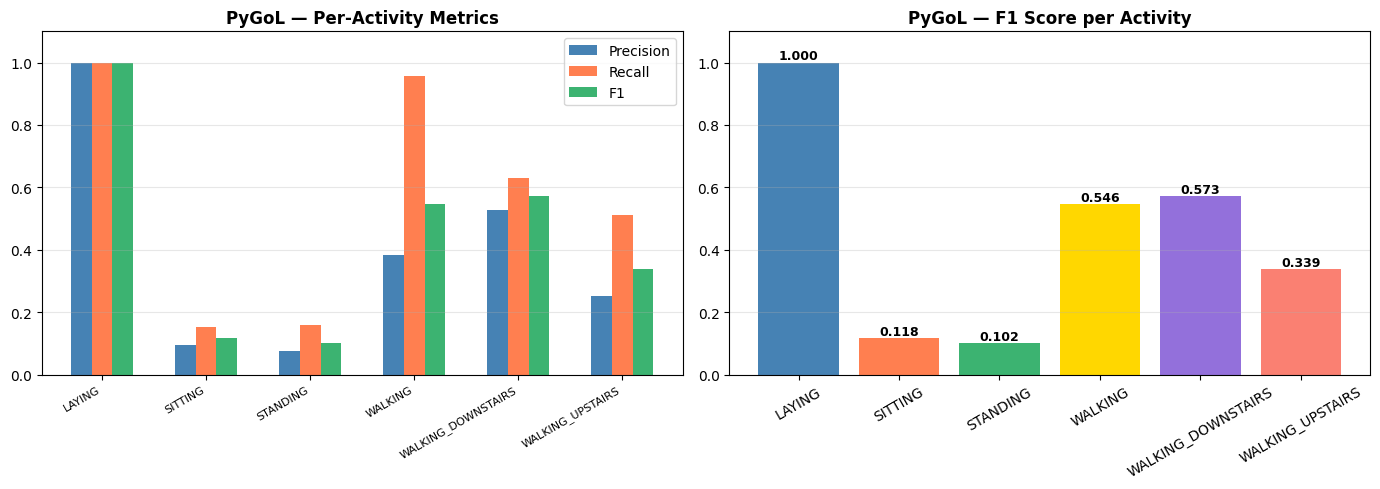

Saved: outputs/pygol_har/01_per_activity_metrics.png


In [5]:
colors = ['steelblue','coral','mediumseagreen','gold','mediumpurple','salmon']
acts   = res_df['activity'].tolist()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
x = np.arange(len(acts))
w = 0.2
axes[0].bar(x-w,   res_df['precision'], w, label='Precision', color='steelblue')
axes[0].bar(x,     res_df['recall'],    w, label='Recall',    color='coral')
axes[0].bar(x+w,   res_df['f1'],        w, label='F1',        color='mediumseagreen')
axes[0].set_xticks(x)
axes[0].set_xticklabels(acts, rotation=30, ha='right', fontsize=8)
axes[0].set_title('PyGoL — Per-Activity Metrics', fontweight='bold')
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)
axes[0].set_ylim(0, 1.1)

axes[1].bar(acts, res_df['f1'], color=colors)
axes[1].set_title('PyGoL — F1 Score per Activity', fontweight='bold')
axes[1].set_ylim(0, 1.1)
axes[1].tick_params(axis='x', rotation=30)
axes[1].grid(axis='y', alpha=0.3)
for i, v in enumerate(res_df['f1']):
    axes[1].text(i, v+0.01, f'{v:.3f}', ha='center', fontsize=9, fontweight='bold')

plt.tight_layout()
plt.savefig('outputs/pygol_har/01_per_activity_metrics.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: outputs/pygol_har/01_per_activity_metrics.png")

## Summary

In [6]:
print("=" * 60)
print("PyGoL ILP — FINAL RESULTS SUMMARY")
print("=" * 60)
print(f"Average Accuracy   : {res_df['accuracy'].mean():.4f}")
print(f"Average Precision  : {res_df['precision'].mean():.4f}")
print(f"Average Recall     : {res_df['recall'].mean():.4f}")
print(f"Average F1         : {res_df['f1'].mean():.4f}")
print(f"Average MCC        : {res_df['mcc'].mean():.4f}")
print(f"\nKey advantage: PyGoL produces interpretable Prolog rules.")
print(f"LAYING achieves F1=1.000 — unique negative gravity signature.")
print(f"SITTING/STANDING are hardest — single rules insufficient for static activities.")
print(f"\nOutput files saved to: outputs/pygol_har/")

PyGoL ILP — FINAL RESULTS SUMMARY
Average Accuracy   : 0.7314
Average Precision  : 0.3886
Average Recall     : 0.5684
Average F1         : 0.4461
Average MCC        : 0.3046

Key advantage: PyGoL produces interpretable Prolog rules.
LAYING achieves F1=1.000 — unique negative gravity signature.
SITTING/STANDING are hardest — single rules insufficient for static activities.

Output files saved to: outputs/pygol_har/
